# Фаза 3 — защита через декорреляцию (на готовых весах)

Step2 показал ключевое: CNN↔CNN ошибаются похоже (каппа ~0.65, перенос сильный), а CNN↔ViT — по-разному (каппа ~0.2, перенос слабый). Значит **архитектурное разнообразие само по себе — это защита**, и её можно продемонстрировать без обучения, прямо на твоих весах (3 ResNet + 3 ViT).

Идея демонстрации: атакующий строит возмущение на суррогате одной архитектуры. Оно переносится на членов **той же** архитектуры, но не на другую. Поэтому:
- **однородный ансамбль** (только CNN или только ViT) валится, когда суррогат совпадает с его архитектурой;
- **смешанный ансамбль** (CNN+ViT) устойчив к **любому** суррогату — один тип атаки не может обмануть всех членов разом.

Меряем robust accuracy и ambiguity (разнообразие ансамбля) под transfer-атаками с двух суррогатов — CNN и ViT.

Всё на 224 (ради ViT). В самом конце — опциональная секция ADP (алгоритмическая декорреляция): это единственная часть, требующая обучения, по умолчанию выключена; включи, если нужны ADP-веса для Фазы 4.

In [1]:
!pip install timm -q
import os, math, zipfile, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE   = 224
SEEDS      = [0, 42, 67]
VIT_NAME   = "vit_small_patch14_dinov2.lvd142m"

SURR_SEED  = 67
ENS_SEEDS  = [0, 42]

EPS_LIST   = [1, 2, 4, 8, 16]
PGD_STEPS  = 7
EVAL_N     = 500
EVAL_BS    = 32

TRAIN_ADP  = True
ADP_ALPHA  = 2.0
ADP_BETA   = 0.5
ADP_EPOCHS = 25
ADP_SEEDS  = [20, 21, 22]

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

CKPT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
REPACK_DIR = Path("/kaggle/working/repacked"); REPACK_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Device: cuda


In [2]:
def locate_imagewoof():
    work = Path("/kaggle/working/data") if Path("/kaggle/working").exists() else Path("./data")
    work.mkdir(parents=True, exist_ok=True)
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise RuntimeError("Папка /kaggle/input не найдена.")
    for p in sorted(input_root.rglob("train")):
        if not p.is_dir():
            continue
        parent = p.parent
        for vn in ("val", "validation", "test"):
            if (parent / vn).is_dir():
                return parent, vn
    import tarfile
    for p in [q for ext in ("*.tgz", "*.tar.gz", "*.zip") for q in input_root.rglob(ext)]:
        if p.suffix == ".zip":
            with zipfile.ZipFile(p) as z: z.extractall(work)
        else:
            with tarfile.open(p) as tar: tar.extractall(work)
        for root, dirs, files in os.walk(work):
            dl = [d.lower() for d in dirs]
            if "train" in dl:
                rp = Path(root)
                for vn in ("val", "validation", "test"):
                    if vn in dl:
                        return rp, dirs[dl.index(vn)]
    raise RuntimeError("Не нашёл train/ + val.")

DATA_ROOT, VAL_DIRNAME = locate_imagewoof()

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_set = torchvision.datasets.ImageFolder(DATA_ROOT / "train", transform=train_tf)
val_set   = torchvision.datasets.ImageFolder(DATA_ROOT / VAL_DIRNAME, transform=eval_tf)
CLASSES = train_set.classes
NUM_CLASSES = len(CLASSES)

val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
n_sub = min(EVAL_N, len(val_set))
eval_loader = DataLoader(Subset(val_set, list(range(n_sub))), batch_size=EVAL_BS,
                         shuffle=False, num_workers=2, pin_memory=True)
print(f"val {len(val_set)} | классов {NUM_CLASSES} | размер {IMG_SIZE} | оценка на {n_sub}")

/tmp/ipykernel_23/827423841.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(p) as tar: tar.extractall(work)


val 3929 | классов 10 | размер 224 | оценка на 500


In [3]:
class NormalizeCNN(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return (x - self.mean) / self.std


class WrappedForInference(nn.Module):
    def __init__(self, net, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        super().__init__()
        self.net = net
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return self.net((x - self.mean) / self.std)


class NormalizedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1))
    def forward(self, x):
        return self.model((x - self.mean) / self.std)


def load_state_from_ckpt(obj):
    if isinstance(obj, dict) and "state_dict" in obj:
        return obj["state_dict"]
    if isinstance(obj, dict) and "model_state_dict" in obj:
        return obj["model_state_dict"]
    return obj


def repack_torch_dir(folder):
    out = REPACK_DIR / (folder.name + ".pth")
    if out.exists():
        return out
    with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as zf:
        for f in folder.rglob("*"):
            if f.is_file():
                zf.write(f, folder.name + "/" + str(f.relative_to(folder)))
    return out


def find_resnet_dir(seed):
    for p in Path("/kaggle/input").rglob("*"):
        low = str(p).lower()
        if "vit" in low:
            continue
        if p.is_dir() and (p / "byteorder").exists():
            if f"seed{seed}" in low or f"seed_{seed}" in low or f"s{seed}" in low:
                return p
    return None


def strip_prefix(sd, anchor="conv1.weight"):
    prefix = ""
    for k in sd:
        if k.endswith(anchor) and "layer" not in k and "downsample" not in k:
            prefix = k[: -len(anchor)]
            break
    bare = {}
    for k, v in sd.items():
        if not k.startswith(prefix):
            continue
        nk = k[len(prefix):]
        if nk in ("mean", "std") or nk.startswith("normalize."):
            continue
        bare[nk] = v
    return bare


def load_resnet_seed(seed):
    folder = find_resnet_dir(seed)
    if folder is None:
        raise FileNotFoundError(f"ResNet seed {seed}: папка-чекпоинт не найдена")
    packed = repack_torch_dir(folder)
    sd = load_state_from_ckpt(torch.load(packed, map_location=DEVICE))
    bare = strip_prefix(sd, "conv1.weight")
    net = torchvision.models.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
    net.load_state_dict(bare, strict=True)
    model = WrappedForInference(net).to(DEVICE).eval()
    print(f"ResNet18-s{seed}: {folder.name}")
    return model


def load_vit_seed(seed):
    path = None
    for p in Path("/kaggle/input").rglob("*.pth"):
        if "vit" in str(p).lower() and f"seed_{seed}" in str(p).lower():
            path = p; break
    if path is None:
        raise FileNotFoundError(f"ViT seed {seed}: .pth не найден")
    sd = load_state_from_ckpt(torch.load(path, map_location=DEVICE))
    prefix = "model." if any(k.startswith("model.") for k in sd) else ""
    pos = sd[prefix + "pos_embed"]
    proj = sd[prefix + "patch_embed.proj.weight"]
    native = proj.shape[-1] * int(round((pos.shape[1] - 1) ** 0.5))
    ncls = sd[prefix + "head.weight"].shape[0]
    base = timm.create_model(VIT_NAME, pretrained=False, num_classes=ncls,
                             img_size=native, dynamic_img_size=True)
    model = NormalizedModel(base).to(DEVICE)
    model.load_state_dict(sd)
    model.eval()
    print(f"ViT-s{seed}: {path.name} (native {native})")
    return model

In [4]:
@torch.no_grad()
def clean_accuracy(net, loader):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (net(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


RESNETS = {s: load_resnet_seed(s) for s in SEEDS}
VITS    = {s: load_vit_seed(s) for s in SEEDS}

cnn_surrogate = RESNETS[SURR_SEED]
vit_surrogate = VITS[SURR_SEED]

print("\nЧистая точность (быстрая проверка, что веса живые):")
for s in ENS_SEEDS:
    print(f"  ResNet-s{s}: {clean_accuracy(RESNETS[s], val_loader)*100:5.2f}%   "
          f"ViT-s{s}: {clean_accuracy(VITS[s], val_loader)*100:5.2f}%")

ResNet18-s0: resnet18_imagewoof_seed0
ResNet18-s42: resnet18_imagewoof_seed42
ResNet18-s67: resnet18_imagewoof_seed67
ViT-s0: vit_imagewoof_seed_0.pth (native 224)
ViT-s42: vit_imagewoof_seed_42.pth (native 224)
ViT-s67: vit_imagewoof_seed_67.pth (native 224)

Чистая точность (быстрая проверка, что веса живые):
  ResNet-s0: 80.05%   ViT-s0: 95.14%
  ResNet-s42: 80.55%   ViT-s42: 95.32%


In [5]:
def fgsm(net, x, y, eps):
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(net(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    return (x + eps * grad.sign()).clamp(0, 1).detach()


def pgd(net, x, y, eps, alpha, steps):
    x_orig = x.clone().detach()
    x_adv = (x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(net(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = (x_orig + (x_adv - x_orig).clamp(-eps, eps)).clamp(0, 1).detach()
    return x_adv


class Ensemble(nn.Module):
    def __init__(self, members):
        super().__init__()
        self.members = members
    def forward(self, x):
        return torch.stack([F.softmax(m(x), dim=1) for m in self.members]).mean(0)


CONFIG_MEMBERS = {
    "CNN x2":   [RESNETS[ENS_SEEDS[0]], RESNETS[ENS_SEEDS[1]]],
    "ViT x2":   [VITS[ENS_SEEDS[0]], VITS[ENS_SEEDS[1]]],
    "Mixed x2": [RESNETS[ENS_SEEDS[0]], VITS[ENS_SEEDS[0]]],
    "Mixed x4": [RESNETS[ENS_SEEDS[0]], RESNETS[ENS_SEEDS[1]], VITS[ENS_SEEDS[0]], VITS[ENS_SEEDS[1]]],
}
CONFIGS = {name: Ensemble(mem) for name, mem in CONFIG_MEMBERS.items()}

print("Чистая точность конфигов:")
for name, ens in CONFIGS.items():
    print(f"  {name:>9}: {clean_accuracy(ens, val_loader)*100:5.2f}%")

Чистая точность конфигов:
     CNN x2: 82.13%
     ViT x2: 95.32%
   Mixed x2: 95.04%
   Mixed x4: 95.32%


## Робастность под transfer-атаками с двух суррогатов

CNN-суррогат (ResNet-s67) и ViT-суррогат (ViT-s67) — оба вне всех ансамблей. Атака PGD генерится на суррогате и проверяется на каждом конфиге. Ожидание: однородный ансамбль валится под «своим» суррогатом, смешанный держит оба.

In [6]:
def robust_transfer(defended, surrogate, loader, eps):
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = pgd(surrogate, x, y, eps, eps / 4, PGD_STEPS)
        with torch.no_grad():
            correct += (defended(x_adv).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


curves = {name: {"cnn_surr": [], "vit_surr": []} for name in CONFIGS}
for e in tqdm(EPS_LIST, desc="robustness vs eps"):
    eps = e / 255
    for name, ens in CONFIGS.items():
        curves[name]["cnn_surr"].append(robust_transfer(ens, cnn_surrogate, eval_loader, eps) * 100)
        curves[name]["vit_surr"].append(robust_transfer(ens, vit_surrogate, eval_loader, eps) * 100)

print("\nRobust accuracy под CNN-суррогатом (PGD), %:")
print("eps  " + "".join(f"{n:>10}" for n in CONFIGS))
for i, e in enumerate(EPS_LIST):
    print(f"{e:>3}  " + "".join(f"{curves[n]['cnn_surr'][i]:>10.1f}" for n in CONFIGS))

robustness vs eps: 100%|██████████| 5/5 [16:39<00:00, 199.88s/it]


Robust accuracy под CNN-суррогатом (PGD), %:
eps      CNN x2    ViT x2  Mixed x2  Mixed x4
  1        70.0      95.8      95.4      95.8
  2        56.2      95.6      95.2      95.0
  4        41.8      96.2      94.6      94.8
  8        22.6      96.2      92.4      92.0
 16         5.6      90.8      84.6      84.0


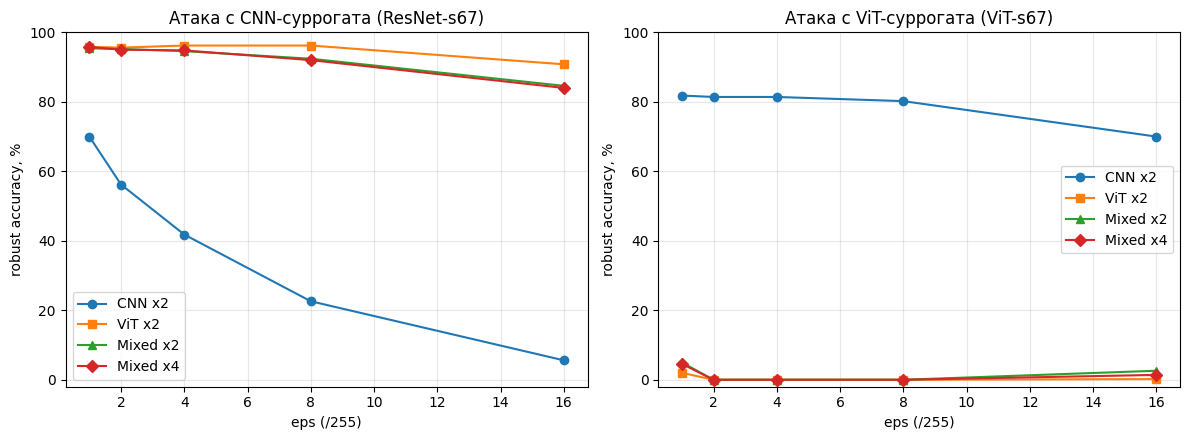

Однородный CNN x2 проваливается под CNN-суррогатом, ViT x2 -- под ViT-суррогатом.
Смешанные конфиги держат обе стороны: один тип суррогата не валит всех членов.


In [7]:
styles = {"CNN x2": "o-", "ViT x2": "s-", "Mixed x2": "^-", "Mixed x4": "D-"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name in CONFIGS:
    ax[0].plot(EPS_LIST, curves[name]["cnn_surr"], styles[name], label=name)
    ax[1].plot(EPS_LIST, curves[name]["vit_surr"], styles[name], label=name)
ax[0].set_title("Атака с CNN-суррогата (ResNet-s67)")
ax[1].set_title("Атака с ViT-суррогата (ViT-s67)")
for a in ax:
    a.set_xlabel("eps (/255)"); a.set_ylabel("robust accuracy, %")
    a.legend(); a.grid(alpha=0.3); a.set_ylim(-2, 100)
plt.tight_layout(); plt.show()

print("Однородный CNN x2 проваливается под CNN-суррогатом, ViT x2 -- под ViT-суррогатом.")
print("Смешанные конфиги держат обе стороны: один тип суррогата не валит всех членов.")

## Ambiguity: разнообразие ансамбля под атакой

Та же метрика, что в исходной Фазе 3. Показываем под CNN-суррогатом: у однородного CNN-ансамбля все члены обмануты разом (ambiguity падает в ноль), у смешанного ViT продолжает голосовать верно (ambiguity держится).

Mixed x4: 100%|██████████| 6/6 [01:08<00:00, 11.41s/it]


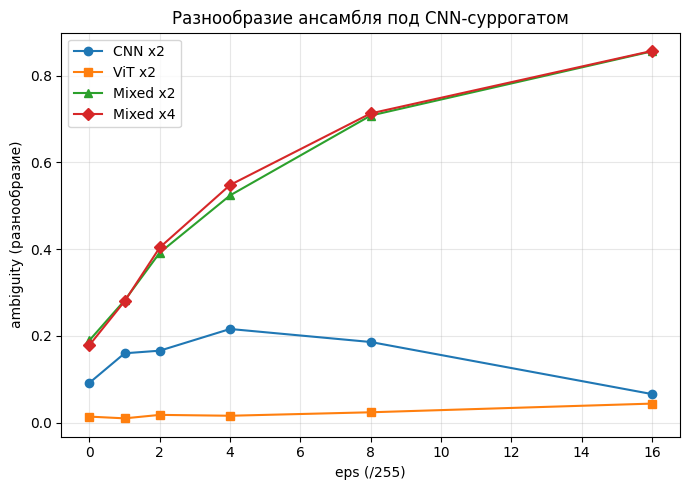

Смешанные конфиги удерживают ambiguity выше -> ViT не даёт CNN-атаке обмануть всех.


In [8]:
def ambiguity(members, surrogate, loader, eps):
    m = len(members)
    denom = m - math.ceil(m / 2)
    total_amb = total_n = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = pgd(surrogate, x, y, eps, eps / 4, PGD_STEPS) if eps > 0 else x
        with torch.no_grad():
            counts = torch.zeros(x.size(0), device=DEVICE)
            for mem in members:
                counts += (mem(x_adv).argmax(1) == y).float()
        amb = torch.minimum(counts, m - counts) / denom
        total_amb += amb.sum().item(); total_n += x.size(0)
    return total_amb / total_n


eps_amb = [0] + EPS_LIST
amb_curves = {}
for name, members in CONFIG_MEMBERS.items():
    amb_curves[name] = [ambiguity(members, cnn_surrogate, eval_loader, e / 255) for e in tqdm(eps_amb, desc=name)]

plt.figure(figsize=(7, 5))
for name in CONFIG_MEMBERS:
    plt.plot(eps_amb, amb_curves[name], styles[name], label=name)
plt.xlabel("eps (/255)"); plt.ylabel("ambiguity (разнообразие)")
plt.title("Разнообразие ансамбля под CNN-суррогатом")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Смешанные конфиги удерживают ambiguity выше -> ViT не даёт CNN-атаке обмануть всех.")

## Вывод по архитектурной декорреляции

Если смешанные конфиги (CNN+ViT) держат robust accuracy и ambiguity под **обоими** суррогатами выше, чем однородные под «своим» суррогатом — архитектурное разнообразие работает как защита без всякого обучения, прямо из твоих весов. Это операционализация вывода step2: раз CNN и ViT ошибаются по-разному (низкая каппа), одно возмущение не валит их одновременно.

Это **архитектурная** нога защиты. Вторая — **алгоритмическая** (ADP, декорреляция предсказаний внутри однородного ансамбля) — единственное, что требует обучения. Ниже опциональная секция: включи `TRAIN_ADP=True`, чтобы обучить ADP-ансамбль ResNet и сохранить веса (`adp_ens_m*.pt`) — они нужны для 2×2 в Фазе 4.

In [9]:
def adp_loss(logits_list, y, alpha, beta, jitter=1e-6):
    m = len(logits_list)
    probs = [F.softmax(l, dim=1) for l in logits_list]
    ece = sum(F.cross_entropy(l, y) for l in logits_list)
    ens = torch.stack(probs).mean(0)
    entropy = -(ens * torch.log(ens + jitter)).sum(1).mean()
    B, L = ens.shape
    mask = torch.ones(B, L, device=y.device).scatter_(1, y.unsqueeze(1), 0.0).bool()
    normed = []
    for p in probs:
        nm = p[mask].view(B, L - 1)
        nm = nm / (nm.norm(dim=1, keepdim=True) + jitter)
        normed.append(nm)
    Mmat = torch.stack(normed, dim=2)
    gram = torch.matmul(Mmat.transpose(1, 2), Mmat)
    eye = torch.eye(m, device=y.device).unsqueeze(0) * jitter
    log_ed = torch.linalg.slogdet(gram + eye)[1].mean()
    return ece - alpha * entropy - beta * log_ed


if TRAIN_ADP:
    print("Обучаю ADP-ансамбль ResNet (это займёт время)...")
    def build_resnet():
        net = torchvision.models.resnet18(weights=None)
        net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
        return WrappedForInference(net).to(DEVICE)

    adp_models = []
    for sd_seed in ADP_SEEDS:
        set_seed(sd_seed)
        adp_models.append(build_resnet())

    train_loader = DataLoader(train_set, batch_size=48, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    params = [p for m in adp_models for p in m.parameters()]
    optimizer = torch.optim.SGD(params, lr=0.1, momentum=0.9, weight_decay=5e-5, nesterov=True)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.1, epochs=ADP_EPOCHS, steps_per_epoch=len(train_loader))

    for epoch in range(ADP_EPOCHS):
        for m in adp_models:
            m.train()
        for x, y in tqdm(train_loader, desc=f"ADP epoch {epoch+1}/{ADP_EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = adp_loss([m(x) for m in adp_models], y, ADP_ALPHA, ADP_BETA)
            loss.backward()
            optimizer.step()
            scheduler.step()

    for i, m in enumerate(adp_models):
        m.eval()
        torch.save({"state_dict": m.state_dict()}, str(CKPT_DIR / f"adp_ens_m{i}.pt"))
    print("ADP-ансамбль обучен и сохранён (adp_ens_m0..2.pt) -- готов для Фазы 4")
else:
    print("ADP-обучение выключено (TRAIN_ADP=False). Архитектурная часть Фазы 3 уже посчитана выше.")

Обучаю ADP-ансамбль ResNet (это займёт время)...


ADP epoch 25/25: 100%|██████████| 188/188 [01:19<00:00,  2.35it/s]


ADP-ансамбль обучен и сохранён (adp_ens_m0..2.pt) -- готов для Фазы 4


Mixed x4: 100%|██████████| 6/6 [03:31<00:00, 35.25s/it]


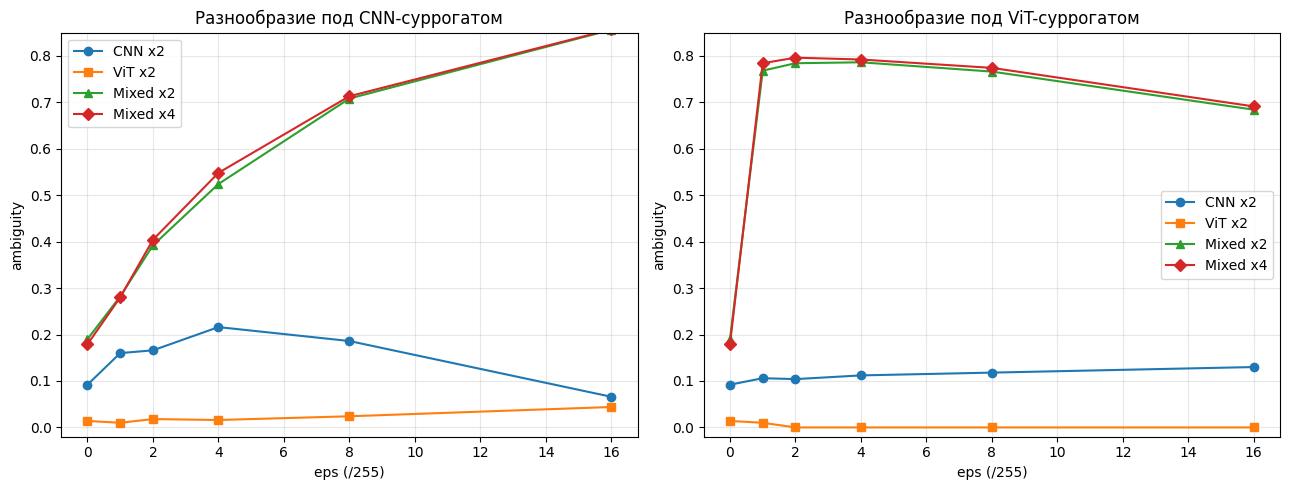

Сравни две стороны: под CNN-суррогатом Mixed держит разнообразие, под ViT — проверь, схлопывается ли.


In [10]:
amb_curves_vit = {}
for name, members in CONFIG_MEMBERS.items():
    amb_curves_vit[name] = [ambiguity(members, vit_surrogate, eval_loader, e / 255) for e in tqdm(eps_amb, desc=name)]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name in CONFIG_MEMBERS:
    ax[0].plot(eps_amb, amb_curves[name], styles[name], label=name)
    ax[1].plot(eps_amb, amb_curves_vit[name], styles[name], label=name)
ax[0].set_title("Разнообразие под CNN-суррогатом")
ax[1].set_title("Разнообразие под ViT-суррогатом")
for a in ax:
    a.set_xlabel("eps (/255)"); a.set_ylabel("ambiguity")
    a.legend(); a.grid(alpha=0.3); a.set_ylim(-0.02, 0.85)
plt.tight_layout(); plt.show()

print("Сравни две стороны: под CNN-суррогатом Mixed держит разнообразие, под ViT — проверь, схлопывается ли.")

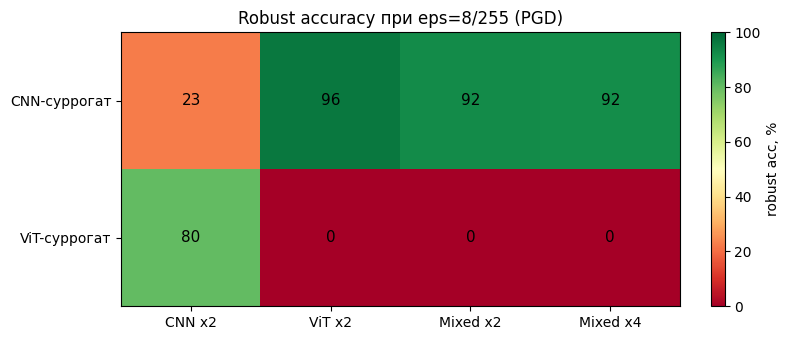

Зелёная строка = конфиг устойчив к этому суррогату. Ищем конфиг, зелёный в ОБЕИХ строках.


In [11]:
eps_focus = 8
idx = EPS_LIST.index(eps_focus)
config_names = list(CONFIGS.keys())

heat = np.array([
    [curves[n]["cnn_surr"][idx] for n in config_names],
    [curves[n]["vit_surr"][idx] for n in config_names],
])

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(heat, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(config_names))); ax.set_xticklabels(config_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(["CNN-суррогат", "ViT-суррогат"])
ax.set_title(f"Robust accuracy при eps={eps_focus}/255 (PGD)")
for i in range(2):
    for j in range(len(config_names)):
        ax.text(j, i, f"{heat[i,j]:.0f}", ha="center", va="center", fontsize=11,
                color="black")
fig.colorbar(im, ax=ax, fraction=0.046, label="robust acc, %")
plt.tight_layout(); plt.show()

print("Зелёная строка = конфиг устойчив к этому суррогату. Ищем конфиг, зелёный в ОБЕИХ строках.")

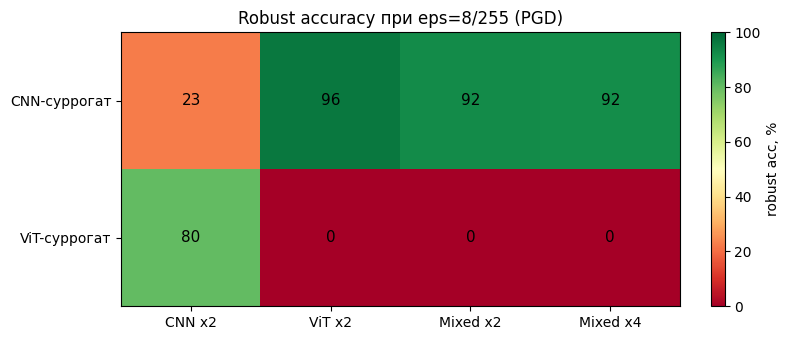

Зелёная строка = конфиг устойчив к этому суррогату. Ищем конфиг, зелёный в ОБЕИХ строках.


In [12]:
eps_focus = 8
idx = EPS_LIST.index(eps_focus)
config_names = list(CONFIGS.keys())

heat = np.array([
    [curves[n]["cnn_surr"][idx] for n in config_names],
    [curves[n]["vit_surr"][idx] for n in config_names],
])

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(heat, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(config_names))); ax.set_xticklabels(config_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(["CNN-суррогат", "ViT-суррогат"])
ax.set_title(f"Robust accuracy при eps={eps_focus}/255 (PGD)")
for i in range(2):
    for j in range(len(config_names)):
        ax.text(j, i, f"{heat[i,j]:.0f}", ha="center", va="center", fontsize=11,
                color="black")
fig.colorbar(im, ax=ax, fraction=0.046, label="robust acc, %")
plt.tight_layout(); plt.show()

print("Зелёная строка = конфиг устойчив к этому суррогату. Ищем конфиг, зелёный в ОБЕИХ строках.")

In [13]:
class VotingEnsemble(nn.Module):
    def __init__(self, members):
        super().__init__()
        self.members = members
    def forward(self, x):
        votes = torch.stack([m(x).argmax(1) for m in self.members], dim=1)
        out = []
        for row in votes:
            vals, counts = torch.unique(row, return_counts=True)
            out.append(vals[counts.argmax()])
        return torch.stack(out)


def robust_transfer_pred(defended, surrogate, loader, eps):
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = pgd(surrogate, x, y, eps, eps / 4, PGD_STEPS)
        with torch.no_grad():
            pred = defended(x_adv)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total


VOTE_CONFIGS = {name: VotingEnsemble(mem) for name, mem in CONFIG_MEMBERS.items()}

vote_curves = {name: {"cnn_surr": [], "vit_surr": []} for name in VOTE_CONFIGS}
for e in tqdm(EPS_LIST, desc="voting robustness"):
    eps = e / 255
    for name, ens in VOTE_CONFIGS.items():
        vote_curves[name]["cnn_surr"].append(robust_transfer_pred(ens, cnn_surrogate, eval_loader, eps) * 100)
        vote_curves[name]["vit_surr"].append(robust_transfer_pred(ens, vit_surrogate, eval_loader, eps) * 100)

print("Majority voting посчитан")

voting robustness: 100%|██████████| 5/5 [16:41<00:00, 200.31s/it]

Majority voting посчитан


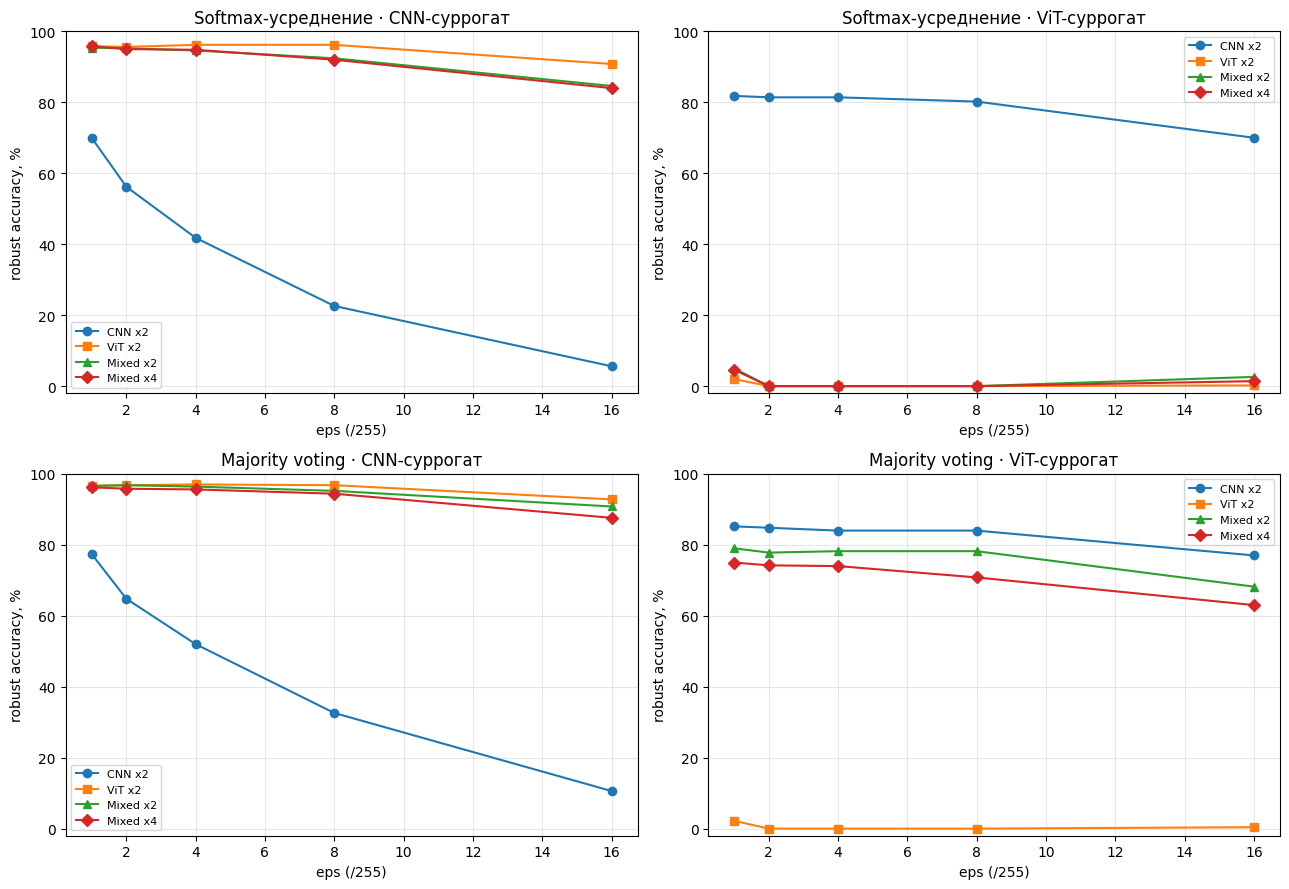

Правый столбец: спасло ли голосование Mixed-конфиги под ViT-суррогатом.
Верхний ряд (softmax) — старый результат, нижний (voting) — новый.


In [14]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

for name in CONFIGS:
    ax[0, 0].plot(EPS_LIST, curves[name]["cnn_surr"], styles[name], label=name)
    ax[0, 1].plot(EPS_LIST, curves[name]["vit_surr"], styles[name], label=name)
    ax[1, 0].plot(EPS_LIST, vote_curves[name]["cnn_surr"], styles[name], label=name)
    ax[1, 1].plot(EPS_LIST, vote_curves[name]["vit_surr"], styles[name], label=name)

ax[0, 0].set_title("Softmax-усреднение · CNN-суррогат")
ax[0, 1].set_title("Softmax-усреднение · ViT-суррогат")
ax[1, 0].set_title("Majority voting · CNN-суррогат")
ax[1, 1].set_title("Majority voting · ViT-суррогат")
for a in ax.flat:
    a.set_xlabel("eps (/255)"); a.set_ylabel("robust accuracy, %")
    a.legend(fontsize=8); a.grid(alpha=0.3); a.set_ylim(-2, 100)
plt.tight_layout(); plt.show()

print("Правый столбец: спасло ли голосование Mixed-конфиги под ViT-суррогатом.")
print("Верхний ряд (softmax) — старый результат, нижний (voting) — новый.")

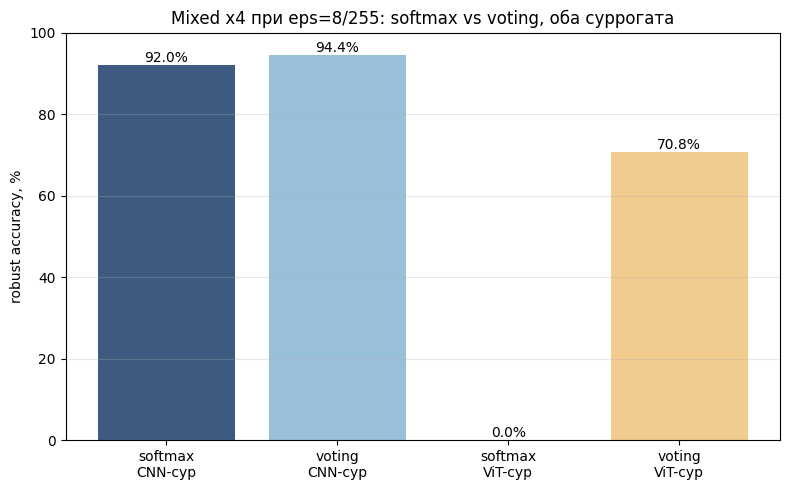

Если синие пары (CNN-сур) примерно равны, а оранжевые (ViT-сур) у voting ВЫШЕ —
значит голосование чинит провал под ViT-суррогатом, и защита становится симметричной.


In [15]:
idx = EPS_LIST.index(8)
labels = ["softmax\nCNN-сур", "voting\nCNN-сур", "softmax\nViT-сур", "voting\nViT-сур"]
vals = [
    curves["Mixed x4"]["cnn_surr"][idx],
    vote_curves["Mixed x4"]["cnn_surr"][idx],
    curves["Mixed x4"]["vit_surr"][idx],
    vote_curves["Mixed x4"]["vit_surr"][idx],
]
colors = ["#3d5a80", "#98c1d9", "#e07a5f", "#f2cc8f"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, vals, color=colors)
ax.bar_label(bars, fmt="%.1f%%", fontsize=10)
ax.set_ylabel("robust accuracy, %")
ax.set_title("Mixed x4 при eps=8/255: softmax vs voting, оба суррогата")
ax.set_ylim(0, 100); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("Если синие пары (CNN-сур) примерно равны, а оранжевые (ViT-сур) у voting ВЫШЕ —")
print("значит голосование чинит провал под ViT-суррогатом, и защита становится симметричной.")

In [16]:
фаза 4

SyntaxError: invalid syntax (2096473168.py, line 1)

In [ ]:
@torch.no_grad()
def clean_accuracy(net, loader):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (net(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


R = {s: load_resnet_seed(s) for s in CNN_SEEDS}
A = {i: load_adp_member(i) for i in ADP_MEMBERS}
V = load_vit_seed(VIT_CFG)

cnn_surrogate = load_resnet_seed(CNN_SURR)
vit_surrogate = load_vit_seed(VIT_SURR)

print("\nЧистая точность загруженных весов:")
for s in CNN_SEEDS:
    print(f"  ResNet-s{s}: {clean_accuracy(R[s], val_loader)*100:5.2f}%")
for i in ADP_MEMBERS:
    print(f"  ADP-m{i}:    {clean_accuracy(A[i], val_loader)*100:5.2f}%")
print(f"  ViT-s{VIT_CFG}:    {clean_accuracy(V, val_loader)*100:5.2f}%")

In [ ]:
def fgsm(net, x, y, eps):
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(net(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    return (x + eps * grad.sign()).clamp(0, 1).detach()


def pgd(net, x, y, eps, alpha, steps):
    x_orig = x.clone().detach()
    x_adv = (x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(net(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = (x_orig + (x_adv - x_orig).clamp(-eps, eps)).clamp(0, 1).detach()
    return x_adv


class Ensemble(nn.Module):
    def __init__(self, members):
        super().__init__()
        self.members = members
    def forward(self, x):
        return torch.stack([F.softmax(m(x), dim=1) for m in self.members]).mean(0)


CONFIG_MEMBERS = {
    "Plain":         [R[CNN_SEEDS[0]], R[CNN_SEEDS[1]]],
    "Algorithmic":   [A[ADP_MEMBERS[0]], A[ADP_MEMBERS[1]]],
    "Architectural": [R[CNN_SEEDS[0]], V],
    "Combination":   [A[ADP_MEMBERS[0]], V],
}
CONFIGS = {name: Ensemble(mem) for name, mem in CONFIG_MEMBERS.items()}

print("Чистая точность конфигов:")
for name, ens in CONFIGS.items():
    print(f"  {name:>14}: {clean_accuracy(ens, val_loader)*100:5.2f}%")

In [ ]:
def robust_transfer(defended, surrogate, loader, eps):
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = pgd(surrogate, x, y, eps, eps / 4, PGD_STEPS)
        with torch.no_grad():
            correct += (defended(x_adv).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


curves = {name: {"cnn": [], "vit": []} for name in CONFIGS}
for e in tqdm(EPS_LIST, desc="robustness vs eps"):
    eps = e / 255
    for name, ens in CONFIGS.items():
        curves[name]["cnn"].append(robust_transfer(ens, cnn_surrogate, eval_loader, eps) * 100)
        curves[name]["vit"].append(robust_transfer(ens, vit_surrogate, eval_loader, eps) * 100)

print("\nRobust accuracy под CNN-суррогатом (PGD), %:")
print("eps  " + "".join(f"{n:>14}" for n in CONFIGS))
for i, e in enumerate(EPS_LIST):
    print(f"{e:>3}  " + "".join(f"{curves[n]['cnn'][i]:>14.1f}" for n in CONFIGS))

In [ ]:
styles = {"Plain": "o-", "Algorithmic": "s-", "Architectural": "^-", "Combination": "D-"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name in CONFIGS:
    ax[0].plot(EPS_LIST, curves[name]["cnn"], styles[name], label=name)
    ax[1].plot(EPS_LIST, curves[name]["vit"], styles[name], label=name)
ax[0].set_title("Атака с CNN-суррогата (R67)")
ax[1].set_title("Атака с ViT-суррогата (V67)")
for a in ax:
    a.set_xlabel("eps (/255)"); a.set_ylabel("robust accuracy, %")
    a.legend(); a.grid(alpha=0.3); a.set_ylim(-2, 100)
plt.tight_layout(); plt.show()

In [ ]:
idx = EPS_LIST.index(EPS_FOCUS)
for surr_key, surr_name in [("cnn", "CNN-суррогат"), ("vit", "ViT-суррогат")]:
    plain = curves["Plain"][surr_key][idx]
    algo  = curves["Algorithmic"][surr_key][idx]
    arch  = curves["Architectural"][surr_key][idx]
    combo = curves["Combination"][surr_key][idx]

    d_algo, d_arch, d_combo = algo - plain, arch - plain, combo - plain
    additive = d_algo + d_arch

    print(f"=== {surr_name}, eps={EPS_FOCUS}/255 ===")
    print(f"  Plain         : {plain:5.1f}%")
    print(f"  Algorithmic   : {algo:5.1f}%   (Δ_algo  = {d_algo:+5.1f})")
    print(f"  Architectural : {arch:5.1f}%   (Δ_arch  = {d_arch:+5.1f})")
    print(f"  Combination   : {combo:5.1f}%   (Δ_combo = {d_combo:+5.1f})")
    print(f"  прогноз Δ_algo+Δ_arch = {additive:+5.1f}")
    diff = d_combo - additive
    if abs(diff) < 3:
        verdict = "аддитивно (эффекты складываются)"
    elif diff < 0:
        verdict = "суб-аддитивно (одна съедает другую)"
    else:
        verdict = "супер-аддитивно (синергия)"
    print(f"  Δ_combo - прогноз = {diff:+5.1f}  ->  {verdict}\n")

In [ ]:
labels = list(CONFIGS.keys())
cnn_vals = [curves[n]["cnn"][idx] for n in labels]
vit_vals = [curves[n]["vit"][idx] for n in labels]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, cnn_vals, w, label="CNN-суррогат", color="#e07a5f")
b2 = ax.bar(x + w/2, vit_vals, w, label="ViT-суррогат", color="#3d5a80")
ax.bar_label(b1, fmt="%.0f", fontsize=9)
ax.bar_label(b2, fmt="%.0f", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("robust accuracy, %")
ax.set_title(f"2×2 при eps={EPS_FOCUS}/255: четыре конфига, оба суррогата")
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

In [ ]:
def ambiguity(members, surrogate, loader, eps):
    m = len(members)
    denom = m - math.ceil(m / 2)
    total_amb = total_n = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = pgd(surrogate, x, y, eps, eps / 4, PGD_STEPS) if eps > 0 else x
        with torch.no_grad():
            counts = torch.zeros(x.size(0), device=DEVICE)
            for mem in members:
                counts += (mem(x_adv).argmax(1) == y).float()
        amb = torch.minimum(counts, m - counts) / denom
        total_amb += amb.sum().item(); total_n += x.size(0)
    return total_amb / total_n


eps_amb = [0] + EPS_LIST
amb_curves = {}
for name, members in CONFIG_MEMBERS.items():
    amb_curves[name] = [ambiguity(members, cnn_surrogate, eval_loader, e / 255) for e in tqdm(eps_amb, desc=name)]

plt.figure(figsize=(7, 5))
for name in CONFIG_MEMBERS:
    plt.plot(eps_amb, amb_curves[name], styles[name], label=name)
plt.xlabel("eps (/255)"); plt.ylabel("ambiguity")
plt.title("Разнообразие конфигов под CNN-суррогатом")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
from pathlib import Path
for i in [0, 1, 2]:
    p = Path("/kaggle/working") / f"adp_ens_m{i}.pt"
    print(f"adp_ens_m{i}.pt:", "есть" if p.exists() else "НЕТ")